In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

pd.set_option("display.float_format", lambda x: f"{x:.4f}")

RANDOM_STATE = 42
HIDDEN_CHANNELS = 64
NUM_LAYERS = 2
DROPOUT = 0.2
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 600
PATIENCE = 20
LR_PATIENCE = 8
LR_FACTOR = 0.5
LOG_EVERY = 10

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ARTIFACTS_DIR = os.path.join("..", "artifacts")
BEST_MODEL_PATH = os.path.join(ARTIFACTS_DIR, "best_model.pt")

torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_STATE)

print(f"Device: {DEVICE}")


Device: cuda


## Data Loading

`graph_dataset.pt` is loaded directly from `energy-model/artifacts/` — the output of the Graph Construction notebook.

In [2]:
dataset_path = os.path.join(ARTIFACTS_DIR, "graph_dataset.pt")
graph_dataset = torch.load(dataset_path, weights_only=False)

train_data = graph_dataset["train"].to(DEVICE)
val_data = graph_dataset["val"].to(DEVICE)
test_data = graph_dataset["test"].to(DEVICE)
meta = graph_dataset["meta"]

FEATURE_COLS = meta["feature_cols"]
IN_CHANNELS = meta["node_feature_dim"]

print(f"Loaded: {dataset_path}")
print(f"Feature dim : {IN_CHANNELS}")
print(f"Features: {FEATURE_COLS}")
print(f"Train: {train_data.num_nodes} nodes {train_data.num_edges} edges")
print(f"Val: {val_data.num_nodes} nodes {val_data.num_edges} edges")
print(f"Test: {test_data.num_nodes} nodes {test_data.num_edges} edges")

Loaded: ../artifacts/graph_dataset.pt
Feature dim : 17
Features: ['length', 'gradient', 'temperature', 'wind_speed', 'speed_kmh', 'battery_soc', 'acceleration', 'surface_type', 'traffic_density', 'weather_condition', 'gradient_sq', 'length_x_gradient', 'cold_penalty', 'wind_speed_sq', 'speed_sq', 'power_proxy', 'speed_x_length']
Train: 3500 nodes 44248 edges
Val: 750 nodes 9664 edges
Test: 750 nodes 9616 edges


## Model Architecture

`EnergyGCN` uses a linear input projection, `NUM_LAYERS` GCNConv blocks with
residual connections, and a scalar head. A **dense skip** connection from the
input projection directly to the final head is added. This connection lets the
model fall back to a direct feature-to-output mapping when neighbourhood
smoothing is not useful, making training more stable and ensuring the GCN
strictly improves over a linear baseline.

- `add_self_loops=False`: self-loops pre-added in graph construction.
- Residual connections preserve node identity across layers.
- Dense skip: `out = head(gcn_out + skip(input_proj))` — GCN must improve
  over the skip path or it is simply zeroed out by optimisation.

In [3]:
class EnergyGCN(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_layers, dropout):
        super().__init__()
        self.input_proj = nn.Linear(in_channels, hidden_channels)
        self.convs = nn.ModuleList([
            GCNConv(hidden_channels, hidden_channels, add_self_loops=False)
            for _ in range(num_layers)
        ])
        self.skip = nn.Linear(hidden_channels, hidden_channels)
        self.head = nn.Linear(hidden_channels, 1)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.relu(self.input_proj(x))
        skip = self.skip(x)

        for conv in self.convs:
            residual = x
            x = conv(x, edge_index)
            x = F.relu(x + residual)
            x = F.dropout(x, p=self.dropout, training=self.training)

        return self.head(x + skip).squeeze(-1)

## Training Setup

In [4]:
model = EnergyGCN(
    in_channels=IN_CHANNELS,
    hidden_channels=HIDDEN_CHANNELS,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(DEVICE)

optimizer = torch.optim.Adam(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=LR_PATIENCE, factor=LR_FACTOR
)
criterion = nn.MSELoss()

total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal parameters: {total_params:,}")
print(f"Device: {DEVICE}")

EnergyGCN(
  (input_proj): Linear(in_features=17, out_features=64, bias=True)
  (convs): ModuleList(
    (0-1): 2 x GCNConv(64, 64)
  )
  (skip): Linear(in_features=64, out_features=64, bias=True)
  (head): Linear(in_features=64, out_features=1, bias=True)
)

Total parameters: 13,697
Device: cuda


## Training Loop

Full-graph forward pass per epoch. Best checkpoint saved on val MSE improvement.
Early stopping fires after `PATIENCE` epochs without improvement.

In [5]:
def train_epoch(model, data, optimizer, criterion):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out, data.y)
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def evaluate(model, data, criterion):
    model.eval()
    out = model(data.x, data.edge_index)
    mse = criterion(out, data.y).item()
    mae = F.l1_loss(out, data.y).item()
    rmse = mse ** 0.5
    return mse, mae, rmse

train_losses = []
val_losses = []
best_val_loss = float("inf")
patience_counter = 0
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(model, train_data, optimizer, criterion)
    val_mse, val_mae, val_rmse = evaluate(model, val_data, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_mse)
    scheduler.step(val_mse)

    if val_mse < best_val_loss:
        best_val_loss    = val_mse
        patience_counter = 0
        torch.save({
            "model_state_dict": model.state_dict(),
            "epoch": epoch,
            "val_mse": val_mse,
            "val_mae": val_mae,
            "hyperparams": {
                "in_channels": IN_CHANNELS,
                "hidden_channels": HIDDEN_CHANNELS,
                "num_layers": NUM_LAYERS,
                "dropout"         : DROPOUT,
            },
        }, BEST_MODEL_PATH)
    else:
        patience_counter += 1

    if epoch % LOG_EVERY == 0:
        lr = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {epoch:>4} | train_mse={train_loss:.4f} | "
            f"val_mse={val_mse:.4f} | val_mae={val_mae:.4f} | "
            f"val_rmse={val_rmse:.4f} | lr={lr:.2e}"
        )

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}  (best val_mse={best_val_loss:.4f})")
        break

print(f"\nBest model saved : {BEST_MODEL_PATH}")

Epoch   10 | train_mse=49.2842 | val_mse=47.7627 | val_mae=6.5643 | val_rmse=6.9111 | lr=1.00e-03
Epoch   20 | train_mse=21.2267 | val_mse=19.2061 | val_mae=3.9283 | val_rmse=4.3825 | lr=1.00e-03
Epoch   30 | train_mse=4.0915 | val_mse=3.1474 | val_mae=1.4409 | val_rmse=1.7741 | lr=1.00e-03
Epoch   40 | train_mse=4.7367 | val_mse=3.6868 | val_mae=1.5152 | val_rmse=1.9201 | lr=5.00e-04
Epoch   50 | train_mse=2.7934 | val_mse=2.1077 | val_mae=1.1491 | val_rmse=1.4518 | lr=5.00e-04
Epoch   60 | train_mse=2.4933 | val_mse=1.9571 | val_mae=1.1260 | val_rmse=1.3990 | lr=5.00e-04
Epoch   70 | train_mse=2.4263 | val_mse=1.9461 | val_mae=1.1238 | val_rmse=1.3950 | lr=2.50e-04
Epoch   80 | train_mse=2.3050 | val_mse=1.8114 | val_mae=1.0811 | val_rmse=1.3459 | lr=2.50e-04
Epoch   90 | train_mse=2.2576 | val_mse=1.7082 | val_mae=1.0460 | val_rmse=1.3070 | lr=2.50e-04
Epoch  100 | train_mse=2.2419 | val_mse=1.6486 | val_mae=1.0269 | val_rmse=1.2840 | lr=2.50e-04
Epoch  110 | train_mse=2.1976 | val_

## Training Curves

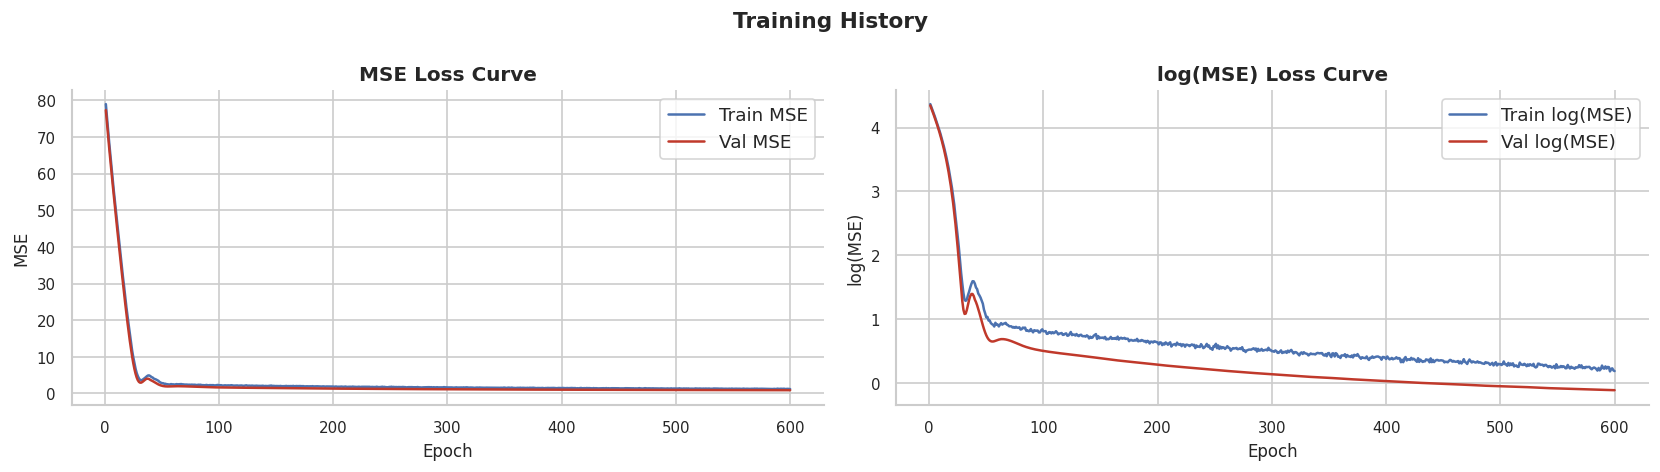

Final train MSE: 1.2024
Best val MSE: 0.8908


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
epochs_range = range(1, len(train_losses) + 1)

axes[0].plot(epochs_range, train_losses, color="#4C72B0", label="Train MSE", linewidth=1.5)
axes[0].plot(epochs_range, val_losses,   color="#c0392b", label="Val MSE",   linewidth=1.5)
axes[0].set_title("MSE Loss Curve", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE")
axes[0].legend()

log_train = [np.log(v + 1e-8) for v in train_losses]
log_val   = [np.log(v + 1e-8) for v in val_losses]
axes[1].plot(epochs_range, log_train, color="#4C72B0", label="Train log(MSE)", linewidth=1.5)
axes[1].plot(epochs_range, log_val,   color="#c0392b", label="Val log(MSE)",   linewidth=1.5)
axes[1].set_title("log(MSE) Loss Curve", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("log(MSE)")
axes[1].legend()

plt.suptitle("Training History", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Final train MSE: {train_losses[-1]:.4f}")
print(f"Best val MSE: {best_val_loss:.4f}")

## Test Set Evaluation

Best checkpoint is reloaded and evaluated on the held-out test set.
Metrics are in raw kWh scale (log1p was not applied).

Loaded checkpoint from epoch 600  (val_mse=0.8908)

Test MSE: 0.9527 kWh^2
Test MAE: 0.7865 kWh
Test RMSE: 0.9761 kWh
Target mean: 8.4478 kWh
RMSE / mean: 11.6%
MAE  / mean: 9.3%


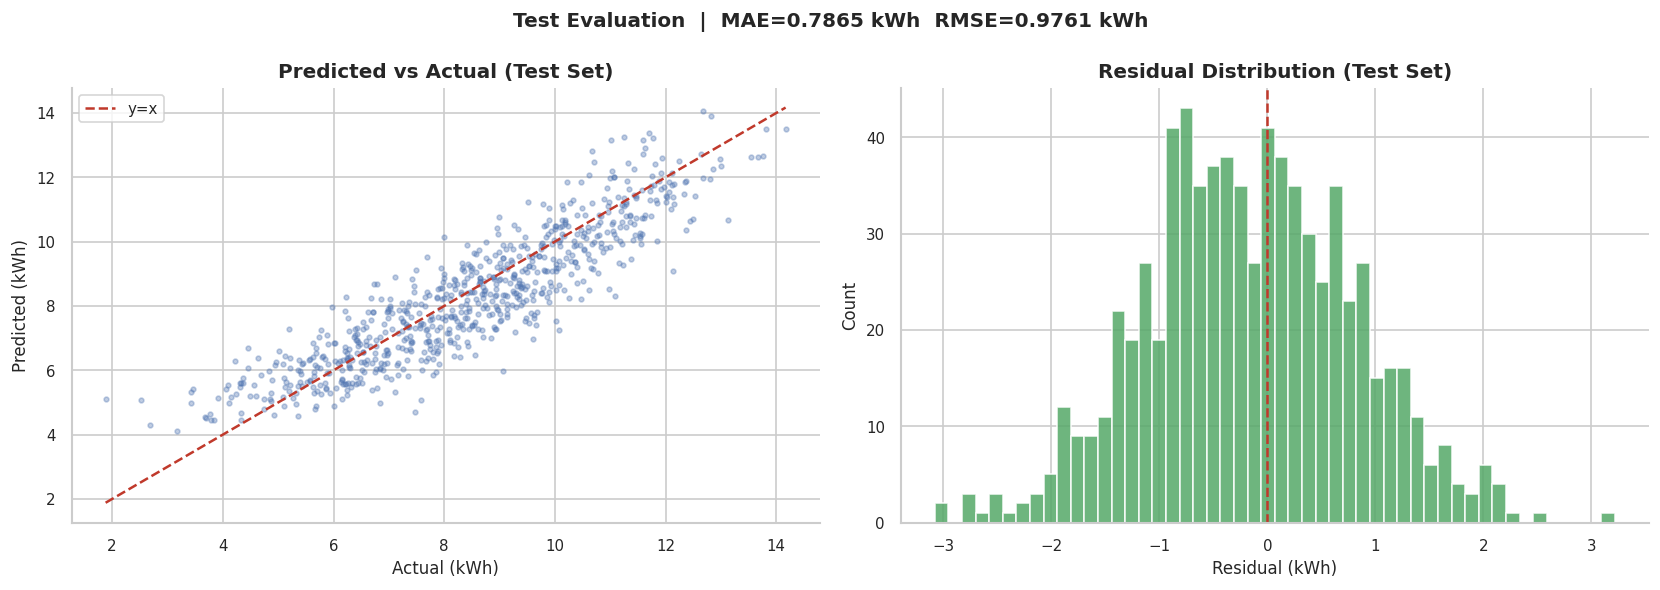

In [7]:
checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
print(f"Loaded checkpoint from epoch {checkpoint['epoch']}  (val_mse={checkpoint['val_mse']:.4f})")

test_mse, test_mae, test_rmse = evaluate(model, test_data, criterion)
target_mean = test_data.y.mean().item()

print(f"\nTest MSE: {test_mse:.4f} kWh^2")
print(f"Test MAE: {test_mae:.4f} kWh")
print(f"Test RMSE: {test_rmse:.4f} kWh")
print(f"Target mean: {target_mean:.4f} kWh")
print(f"RMSE / mean: {test_rmse / target_mean * 100:.1f}%")
print(f"MAE  / mean: {test_mae  / target_mean * 100:.1f}%")

model.eval()
with torch.no_grad():
    preds = model(test_data.x, test_data.edge_index).cpu().numpy()
actuals   = test_data.y.cpu().numpy()
residuals = preds - actuals

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lo, hi = min(actuals.min(), preds.min()), max(actuals.max(), preds.max())
axes[0].scatter(actuals, preds, alpha=0.35, s=8, color="#4C72B0")
axes[0].plot([lo, hi], [lo, hi], color="#c0392b", linewidth=1.5, linestyle="--", label="y=x")
axes[0].set_title("Predicted vs Actual (Test Set)", fontweight="bold")
axes[0].set_xlabel("Actual (kWh)")
axes[0].set_ylabel("Predicted (kWh)")
axes[0].legend(fontsize=9)

axes[1].hist(residuals, bins=50, color="#55A868", edgecolor="white", alpha=0.85)
axes[1].axvline(0, color="#c0392b", linewidth=1.5, linestyle="--")
axes[1].set_title("Residual Distribution (Test Set)", fontweight="bold")
axes[1].set_xlabel("Residual (kWh)")
axes[1].set_ylabel("Count")

plt.suptitle(f"Test Evaluation  |  MAE={test_mae:.4f} kWh  RMSE={test_rmse:.4f} kWh",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## Prediction Sanity Check

Synthetic sweep: `speed_kmh` and `gradient` are varied while all other
features stay at the training mean. `speed_sq` and `speed_x_length` are
updated consistently with the speed value to avoid contradictory inputs.
Expected: monotonic increase with speed (aerodynamic drag ∝ v) and
asymmetric increase with positive gradient (uphill costs more).

In [8]:
speed_idx = FEATURE_COLS.index("speed_kmh")
speed_sq_idx = FEATURE_COLS.index("speed_sq")
sxl_idx = FEATURE_COLS.index("speed_x_length")
length_idx = FEATURE_COLS.index("length")
grad_idx = FEATURE_COLS.index("gradient")
grad_sq_idx = FEATURE_COLS.index("gradient_sq")

x_mean = train_data.x.mean(dim=0)
mean_length = x_mean[length_idx].item()
n_cases = 7

# Speed sweep — update speed_sq and speed_x_length consistently
x_speed = x_mean.unsqueeze(0).repeat(n_cases, 1).clone()
speed_vals = torch.linspace(-1.5, 1.5, n_cases)
x_speed[:, speed_idx]= speed_vals
x_speed[:, speed_sq_idx] = speed_vals ** 2
x_speed[:, sxl_idx]= speed_vals * mean_length

sl_idx = torch.stack([torch.arange(n_cases), torch.arange(n_cases)], dim=0).to(DEVICE)

model.eval()
with torch.no_grad():
    preds_speed = model(x_speed.to(DEVICE), sl_idx).cpu().numpy()

print("Speed sensitivity (consistent speed_sq and speed_x_length update):")
print(f"  {'speed_kmh (scaled)':<26}  predicted energy (kWh)")
print("  " + "-" * 50)
for s, p in zip(speed_vals.numpy(), preds_speed):
    trend = " <-- mean" if abs(s) < 0.01 else ""
    print(f"  {s:>+.2f}{'':22}  {p:.4f}{trend}")

# Gradient sweep — update gradient_sq consistently
x_grad = x_mean.unsqueeze(0).repeat(n_cases, 1).clone()
grad_vals = torch.linspace(-1.5, 1.5, n_cases)
x_grad[:, grad_idx]    = grad_vals
x_grad[:, grad_sq_idx] = grad_vals ** 2

with torch.no_grad():
    preds_grad = model(x_grad.to(DEVICE), sl_idx).cpu().numpy()

print("\nGradient sensitivity (gradient_sq updated consistently):")
print(f" {'gradient (scaled)':<26}  predicted energy (kWh)")
print("  " + "-" * 50)
for g, p in zip(grad_vals.numpy(), preds_grad):
    trend = " <-- mean" if abs(g) < 0.01 else ""
    print(f"  {g:>+.2f}{'':22}  {p:.4f}{trend}")

Speed sensitivity (consistent speed_sq and speed_x_length update):
  speed_kmh (scaled)          predicted energy (kWh)
  --------------------------------------------------
  -1.50                        4.3379
  -1.00                        3.1697
  -0.50                        2.9172
  +0.00                        3.5049 <-- mean
  +0.50                        4.4348
  +1.00                        5.9529
  +1.50                        7.9795

Gradient sensitivity (gradient_sq updated consistently):
 gradient (scaled)           predicted energy (kWh)
  --------------------------------------------------
  -1.50                        4.2540
  -1.00                        3.5203
  -0.50                        3.3051
  +0.00                        3.5049 <-- mean
  +0.50                        3.8060
  +1.00                        4.5290
  +1.50                        5.8805


## Artifact Export

In [9]:
size_kb = os.path.getsize(BEST_MODEL_PATH) / 1024
ckpt = torch.load(BEST_MODEL_PATH, map_location="cpu", weights_only=False)

print(f"Artifact: {BEST_MODEL_PATH}")
print(f"Size: {size_kb:.1f} KB")
print(f"Saved epoch: {ckpt['epoch']}")
print(f"Val MSE: {ckpt['val_mse']:.4f}")
print(f"Val MAE: {ckpt['val_mae']:.4f}")
print(f"Hyperparams: {ckpt['hyperparams']}")

Artifact: ../artifacts/best_model.pt
Size: 58.0 KB
Saved epoch: 600
Val MSE: 0.8908
Val MAE: 0.7473
Hyperparams: {'in_channels': 17, 'hidden_channels': 64, 'num_layers': 2, 'dropout': 0.2}


## Summary

In [10]:
summary = {
    "best_epoch": ckpt["epoch"],
    "val_mse": round(ckpt["val_mse"], 4),
    "val_mae": round(ckpt["val_mae"], 4),
    "test_mse": round(test_mse, 4),
    "test_mae": round(test_mae, 4),
    "test_rmse": round(test_rmse, 4),
    "target_mean_kwh": round(target_mean, 4),
    "rmse_pct": round(test_rmse / target_mean * 100, 1),
    "feature_dim": IN_CHANNELS,
    "hidden_channels": HIDDEN_CHANNELS,
    "num_layers": NUM_LAYERS,
    "best_model_path": BEST_MODEL_PATH,
}

print("=" * 62)
print("TRAINING SUMMARY")
print("=" * 62)
for k, v in summary.items():
    print(f"  {k:<22}: {v}")
print("=" * 62)
print("\nHandoff to: predictor/inference.py")
print(f"  Load  : {BEST_MODEL_PATH}")
print(f"  Class : EnergyGCN(in_channels={IN_CHANNELS}, hidden_channels={HIDDEN_CHANNELS}, "
      f"num_layers={NUM_LAYERS}, dropout={DROPOUT})")

TRAINING SUMMARY
  best_epoch            : 600
  val_mse               : 0.8908
  val_mae               : 0.7473
  test_mse              : 0.9527
  test_mae              : 0.7865
  test_rmse             : 0.9761
  target_mean_kwh       : 8.4478
  rmse_pct              : 11.6
  feature_dim           : 17
  hidden_channels       : 64
  num_layers            : 2
  best_model_path       : ../artifacts/best_model.pt

Handoff to: predictor/inference.py
  Load  : ../artifacts/best_model.pt
  Class : EnergyGCN(in_channels=17, hidden_channels=64, num_layers=2, dropout=0.2)


In [11]:
training_summary = {
    "best_epoch": int(ckpt["epoch"]),
    "val_mse": round(ckpt["val_mse"], 4),
    "val_mae": round(ckpt["val_mae"], 4),
    "test_mse": round(test_mse, 4),
    "test_mae": round(test_mae, 4),
    "test_rmse": round(test_rmse, 4),
    "target_mean_kwh": round(target_mean, 4),
    "rmse_pct": round(test_rmse / target_mean * 100, 1),
    "feature_dim": IN_CHANNELS,
    "hidden_channels": HIDDEN_CHANNELS,
    "num_layers": NUM_LAYERS,
    "dropout": DROPOUT,
    "feature_cols": FEATURE_COLS,
    "knn_graph_cols": meta["knn_graph_cols"],
    "best_model_path": BEST_MODEL_PATH
}

os.makedirs(ARTIFACTS_DIR, exist_ok=True)
summary_path = os.path.join(ARTIFACTS_DIR, "training_summary.json")
with open(summary_path, "w") as fh:
    json.dump(training_summary, fh, indent=2)

print(f"Saved: {summary_path}  ({os.path.getsize(summary_path)} bytes)")
for k, v in training_summary.items():
    print(f"  {k:<22}: {v}")

Saved: ../artifacts/training_summary.json  (745 bytes)
  best_epoch            : 600
  val_mse               : 0.8908
  val_mae               : 0.7473
  test_mse              : 0.9527
  test_mae              : 0.7865
  test_rmse             : 0.9761
  target_mean_kwh       : 8.4478
  rmse_pct              : 11.6
  feature_dim           : 17
  hidden_channels       : 64
  num_layers            : 2
  dropout               : 0.2
  feature_cols          : ['length', 'gradient', 'temperature', 'wind_speed', 'speed_kmh', 'battery_soc', 'acceleration', 'surface_type', 'traffic_density', 'weather_condition', 'gradient_sq', 'length_x_gradient', 'cold_penalty', 'wind_speed_sq', 'speed_sq', 'power_proxy', 'speed_x_length']
  knn_graph_cols        : ['speed_kmh', 'length', 'gradient']
  best_model_path       : ../artifacts/best_model.pt
